In [545]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix,classification_report,roc_auc_score,log_loss,precision_recall_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
import requests
import io
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="dark")
pd.set_option('display.max_columns', 0)
# plt.style.use('ggplot')
pd.options.display.float_format = '{:.2f}'.format
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform, loguniform
import time
SEED = 42

![Alt text](dataset_description.png)

In [546]:
df = pd.read_csv('./youtube_shorts_performance_dataset.csv')
print(df.shape)

(300, 10)


In [547]:
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


In [548]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB


In [549]:
# checking for columns names
df.columns

Index(['video_id', 'title', 'duration_sec', 'hashtags_count', 'views', 'likes',
       'comments', 'shares', 'upload_hour', 'category'],
      dtype='object')

In [550]:
# missing values
df.isna().sum()

video_id          0
title             0
duration_sec      0
hashtags_count    0
views             0
likes             0
comments          0
shares            0
upload_hour       0
category          0
dtype: int64

In [551]:
df['video_id'].nunique(),df['title'].nunique()

(300, 300)

1. Calculate the Engagement Rate for all Shorts and categorize performance into Low, Medium, and High tertiles. What is the distribution of the target variable, and does it suggest any class imbalance challenges?

In [552]:
df['engagement_rate'] = df.apply(lambda x: (x['likes']+x['comments']+x['shares'])/x['views'],axis=1)
df['engagement_rate'].describe()

count   300.00
mean      0.43
std       1.75
min       0.00
25%       0.06
50%       0.11
75%       0.22
max      21.22
Name: engagement_rate, dtype: float64

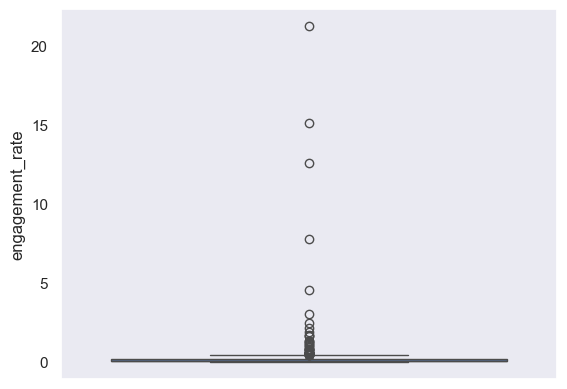

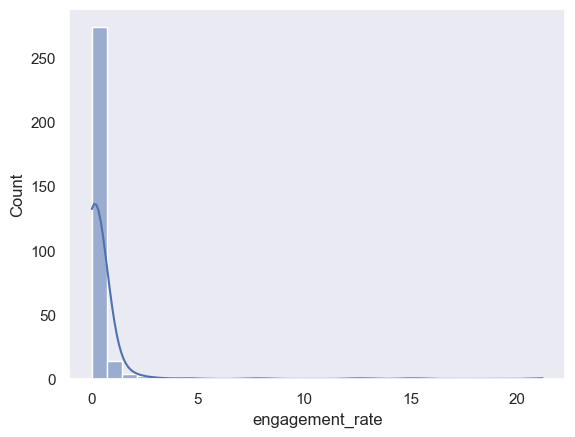

In [553]:
sns.boxplot(data=df,y='engagement_rate')
plt.show()
sns.histplot(data=df,x='engagement_rate',bins=30,kde=True)
plt.show()

- Engagement rate is highly skewed towards the right, mayb there are short videos with views less than likes or other features etc.

In [554]:
len(df[(df['views']<df['likes']) | (df['views']<df['comments']) | (df['views']<df['shares'])])

15

- There are 15 rows with views less than likes or comments or shares, which is not possible in real world scenario, as for a user to like a video he need to view the video first. This is my assumption so dropping off this columns because it is adding noise to the dataset

In [555]:
df = df[~((df['views']<df['likes']) | (df['views']<df['comments']) | (df['views']<df['shares']))]
len(df)

285

In [556]:
df['performance_engagement_tertile'] = pd.qcut(df['engagement_rate'],q=3,labels=['low','medium','high'])
df['performance_engagement_tertile'].value_counts()

performance_engagement_tertile
low       95
medium    95
high      95
Name: count, dtype: int64

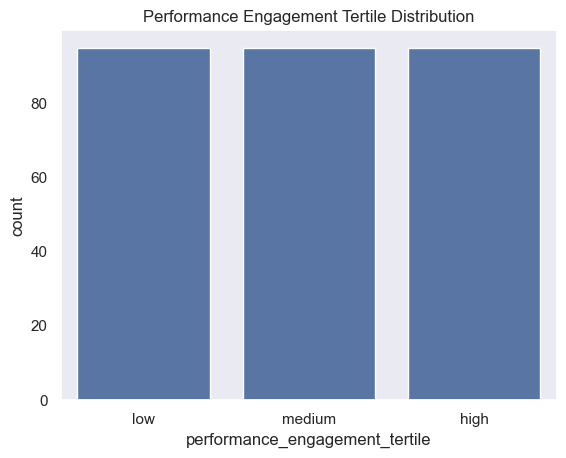

In [557]:
sns.countplot(data = df,x='performance_engagement_tertile')
plt.title('Performance Engagement Tertile Distribution')
plt.show()

- There is no imbalance in the target variable each tertile are having equal amount of rows.

array([[<Axes: title={'center': 'duration_sec'}>,
        <Axes: title={'center': 'hashtags_count'}>,
        <Axes: title={'center': 'views'}>],
       [<Axes: title={'center': 'likes'}>,
        <Axes: title={'center': 'comments'}>,
        <Axes: title={'center': 'shares'}>],
       [<Axes: title={'center': 'upload_hour'}>,
        <Axes: title={'center': 'engagement_rate'}>, <Axes: >]],
      dtype=object)

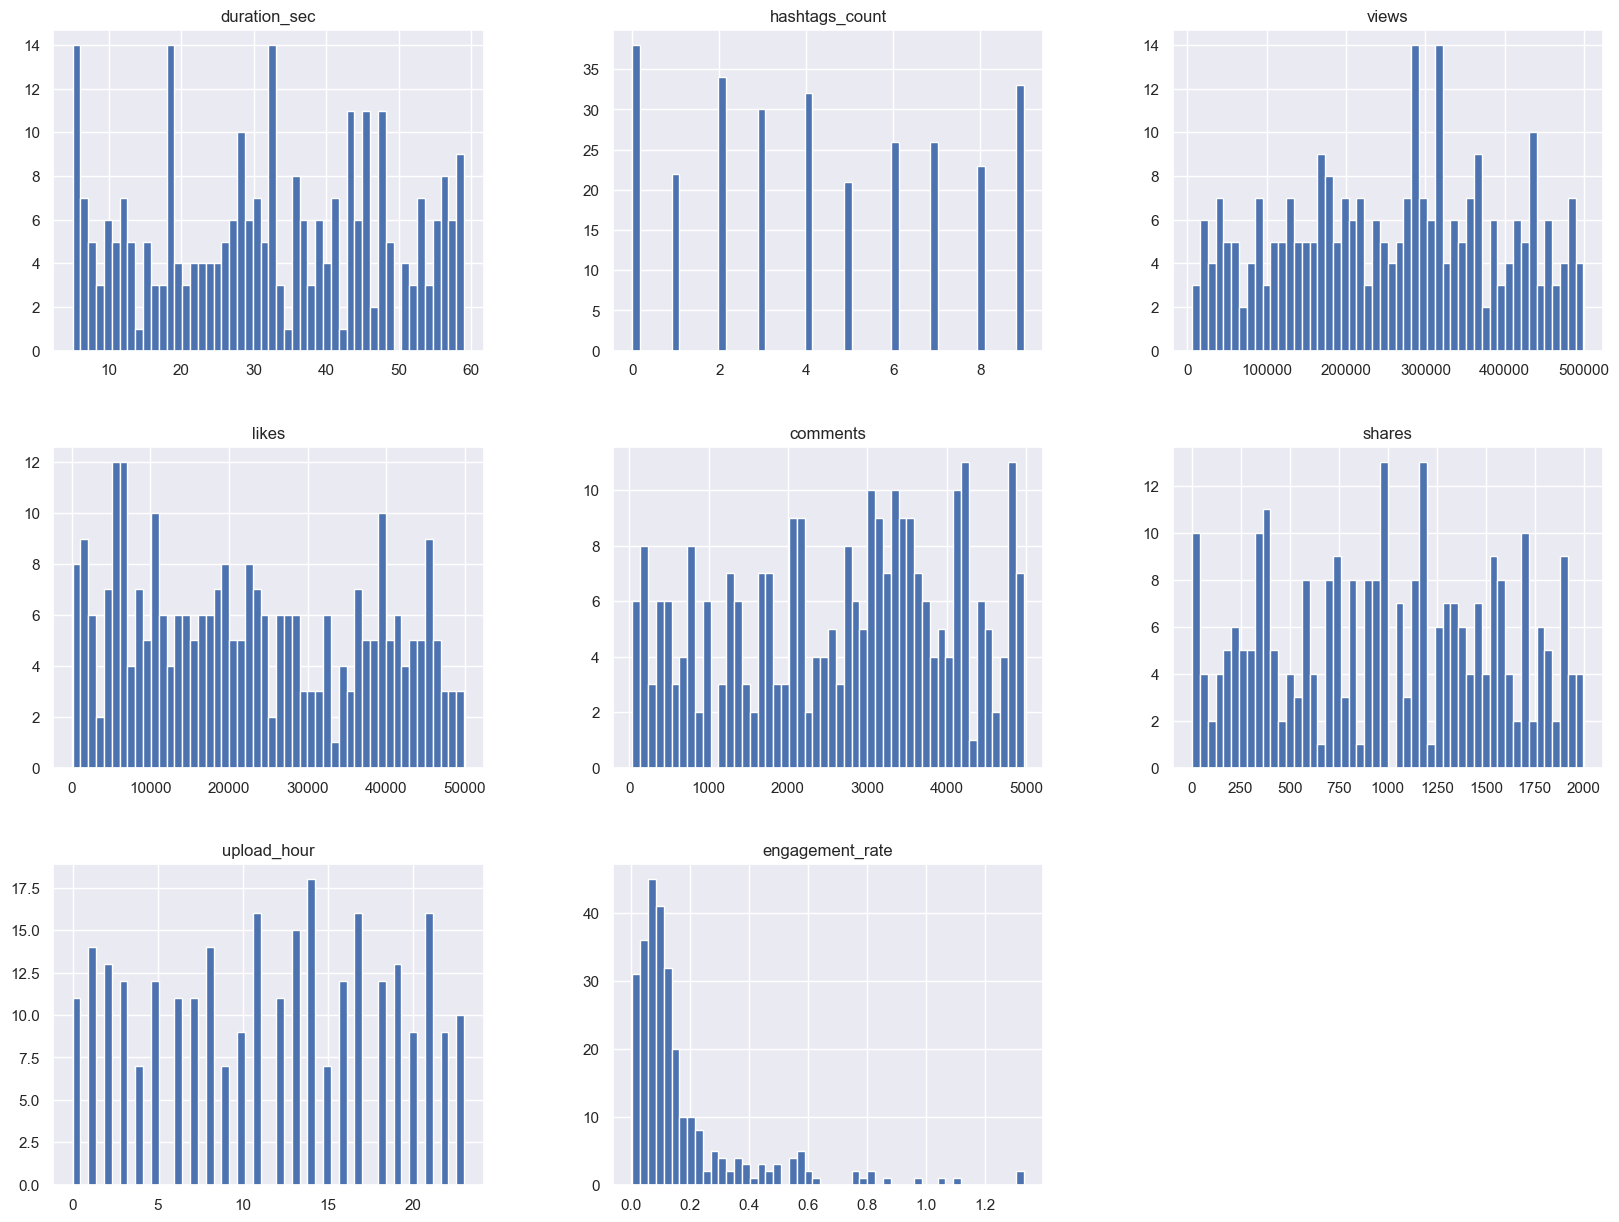

In [558]:
df.hist(figsize=(20,15), bins=50)  

- Engagement Rate is heavily right skewed, there may be short videos with views are less than likes, share and comments combined. 
- I'm using log transformation, to reduce the skewness and reduce the impact of outliers

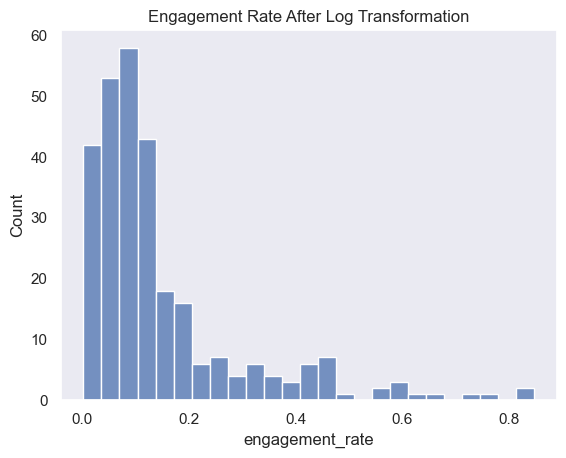

In [559]:
df['engagement_rate'] = df['engagement_rate'].apply(lambda x: np.log1p(x))
sns.histplot(x = df['engagement_rate'])
plt.title('Engagement Rate After Log Transformation')
plt.show()

- After applying log transformation it look much cleaner and closer to normal distribution now, impact of high engagement rate videos is reduced

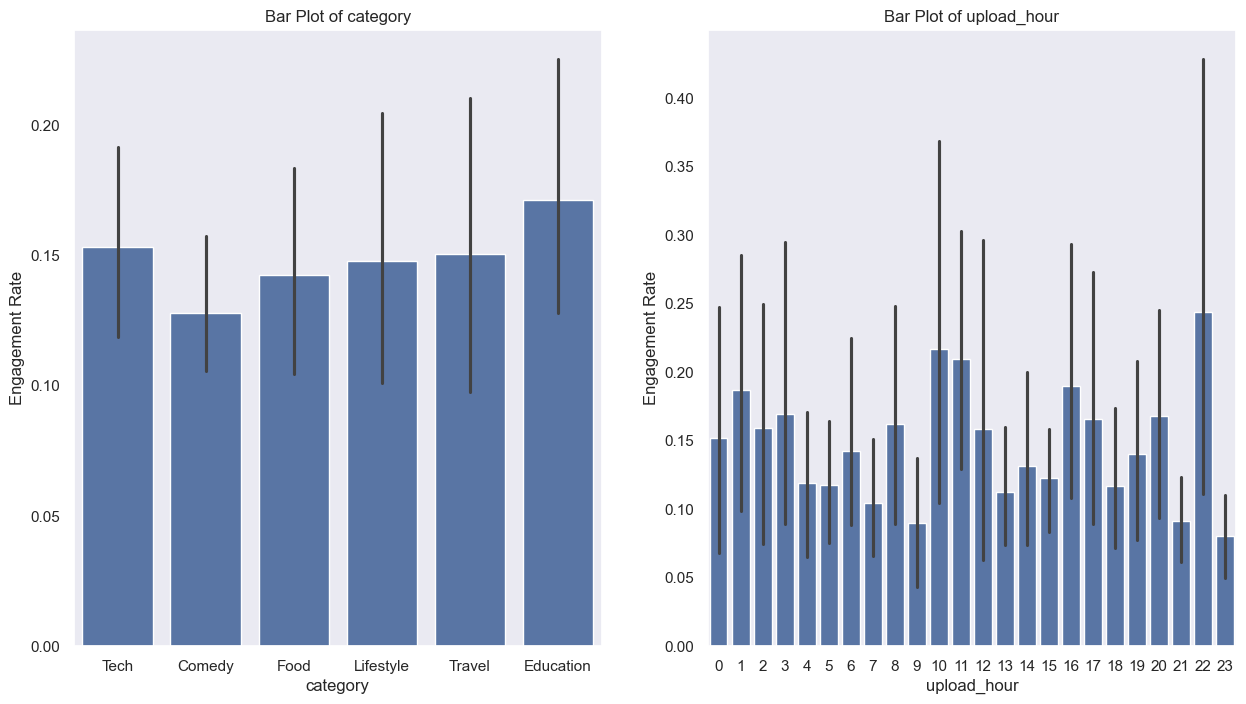

In [560]:
cat_cols = ['category','upload_hour']
fig, axes = plt.subplots(1, 2, figsize=(15,8))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
for i,col in enumerate(cat_cols):
    ax = axes[i]
    sns.barplot(data=df,x=col,y='engagement_rate',ax=ax,estimator='mean')
    ax.set_title(f'Bar Plot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Engagement Rate')

- There are some peak hours like 22,10,11 which are having high engagement rate, large error bar in hour 22 specifies that there are some short videos which went viral and having extremely high engagement rate
- Among different categories Education related shorts are having high engagement rate and also moderate variance, then comes tech related shorts.
- Shorts related to comedy category is having lowest engagement rate but consistent with less variance, then food related shorts are having second lowest engagement rate

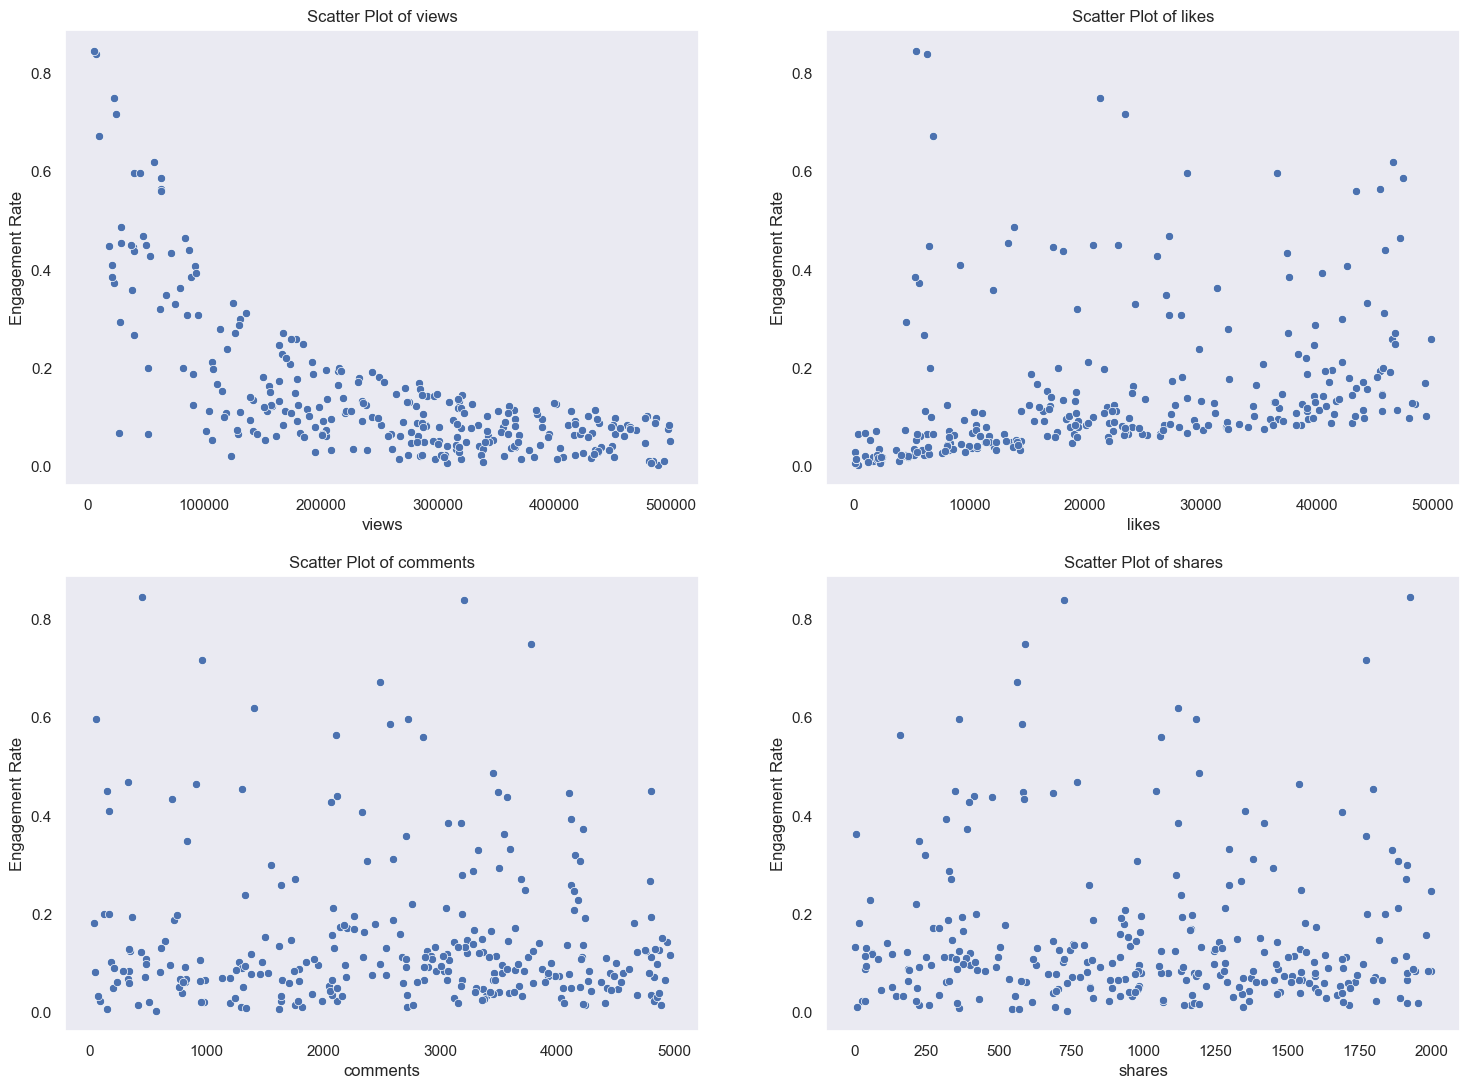

In [561]:
num_cols = ['views','likes','comments','shares']
fig, axes = plt.subplots(2, 2, figsize=(18,13))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
for i,col in enumerate(num_cols):
    ax = axes[i]
    sns.scatterplot(data=df,x=col,y='engagement_rate',ax=ax)
    ax.set_title(f'Scatter Plot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Engagement Rate')



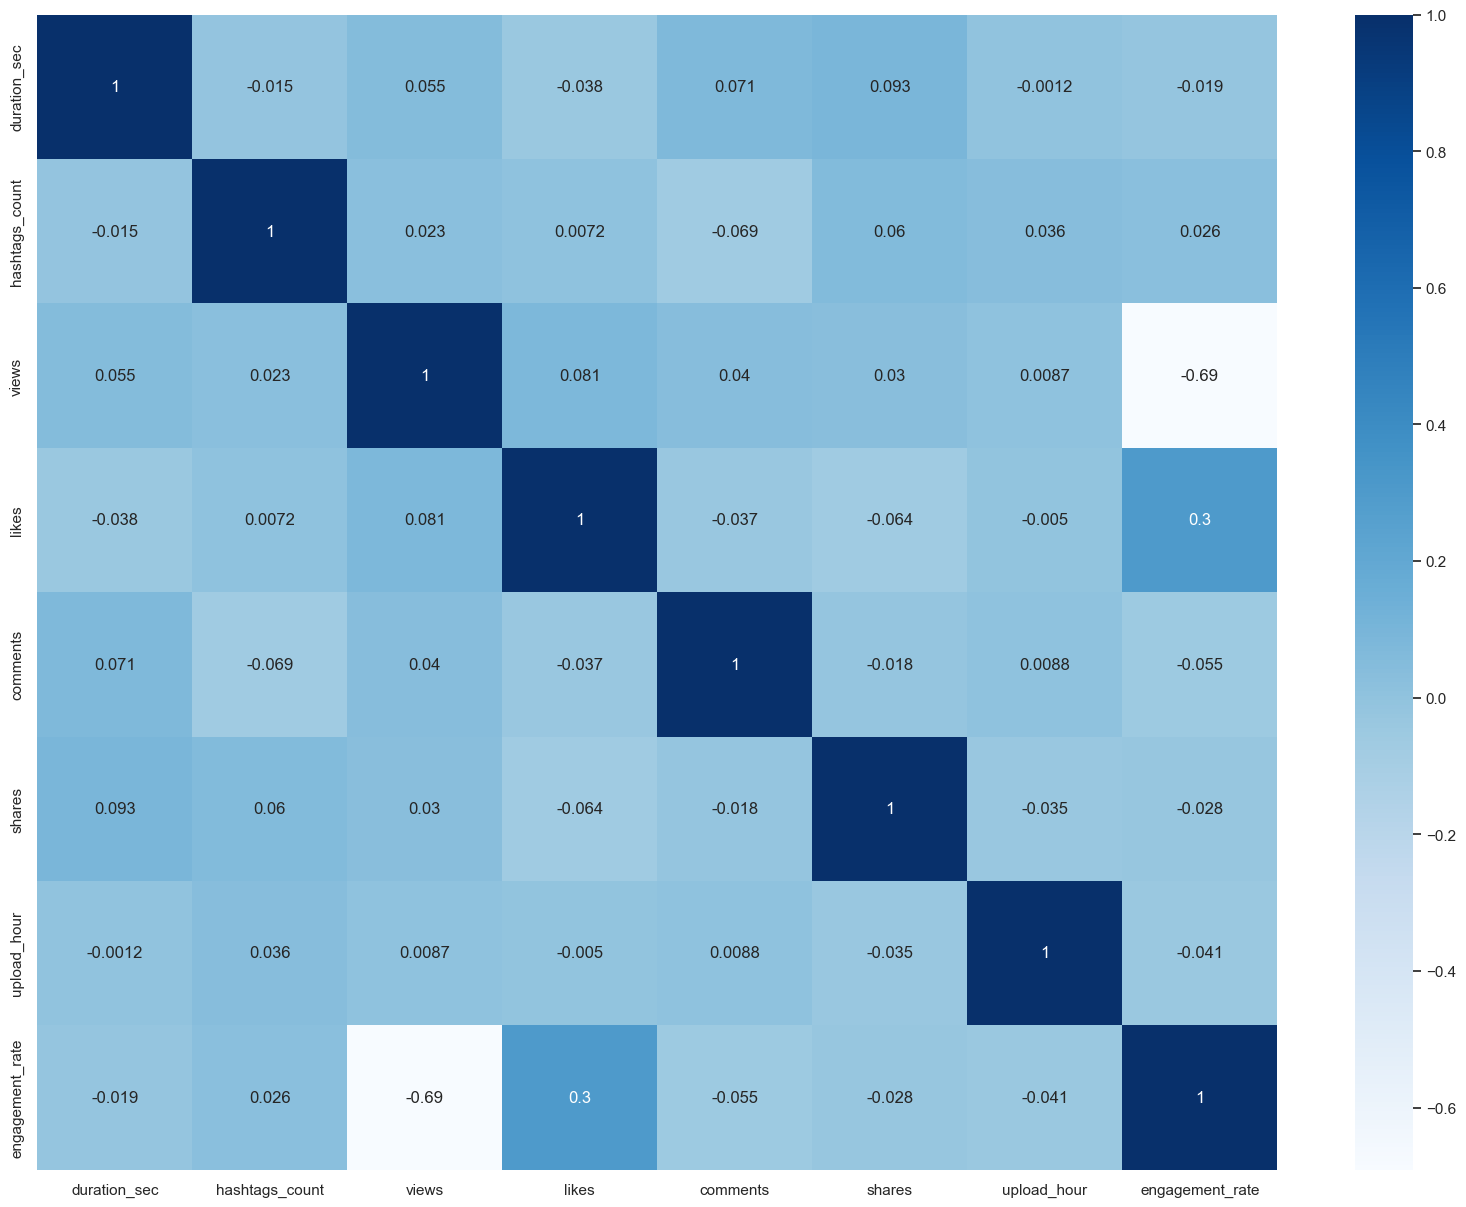

In [562]:
corr_mat = df.corr(numeric_only=True)
plt.figure(figsize=(20, 15))
corr_heatmap=sns.heatmap(df.corr(numeric_only=True), cmap="Blues", annot=True)

- There is a negative correlation between engagement_rate and views, that means as views count increases engagement rate will reduce which is also confirmed in the scatter plot
- There is a positive correlation between engagement_rate and likes, that means as likes increases engagement rate also increases, which is also confirmed in above scatterplot between them
- Most features like (duration_sec vs hashtags_count) are having near zero correlation. It means each feature provides unique, independent information.

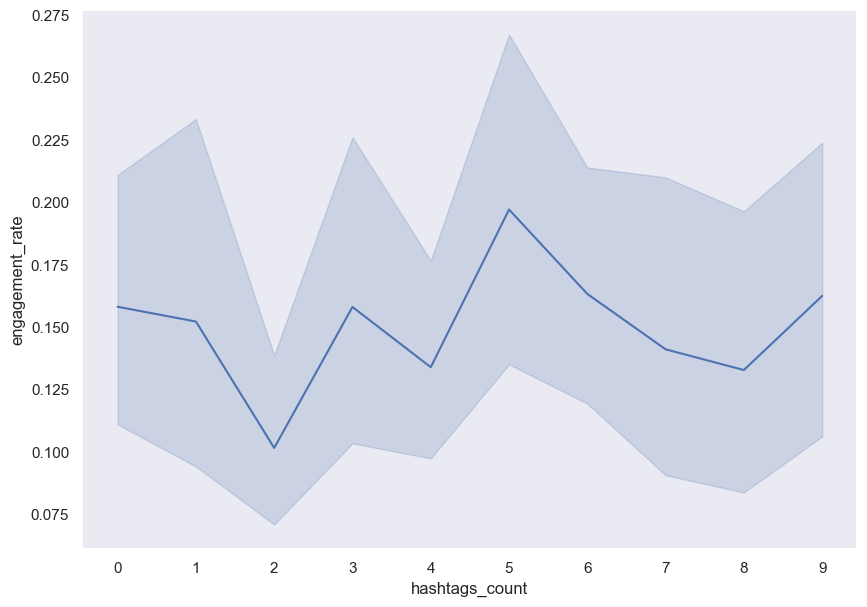

In [563]:
plt.figure(figsize=(10,7))
sns.lineplot(data=df,x='hashtags_count',y='engagement_rate')
plt.xticks(range(0, 10, 1))
plt.show()

- line plot for hashtags_count shows two major peaks at 3 and 5 hashtags count. Also, there is a massive dip at 2.
- This suggest that the relationship is non linear, and tree based models will be better and linear regression might fail here

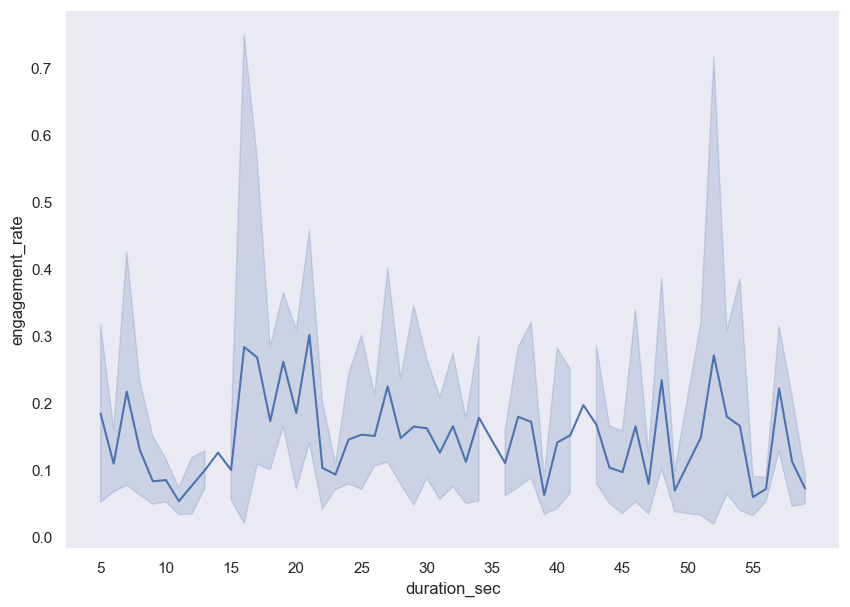

In [564]:
plt.figure(figsize=(10,7))
sns.lineplot(data=df,x='duration_sec',y='engagement_rate')
plt.xticks(range(5, 60, 5))
plt.show()

- The duration_sec plot shows extreme spikes 22,16,52,17,19 seconds.
- These are likely the sweet spots where engagement is maximized.

In [565]:
peak_duration_sec = [22,16,52,17,19]
df['is_peak_duration_sec'] = df['duration_sec'].apply(lambda x: 1 if x in peak_duration_sec else 0)

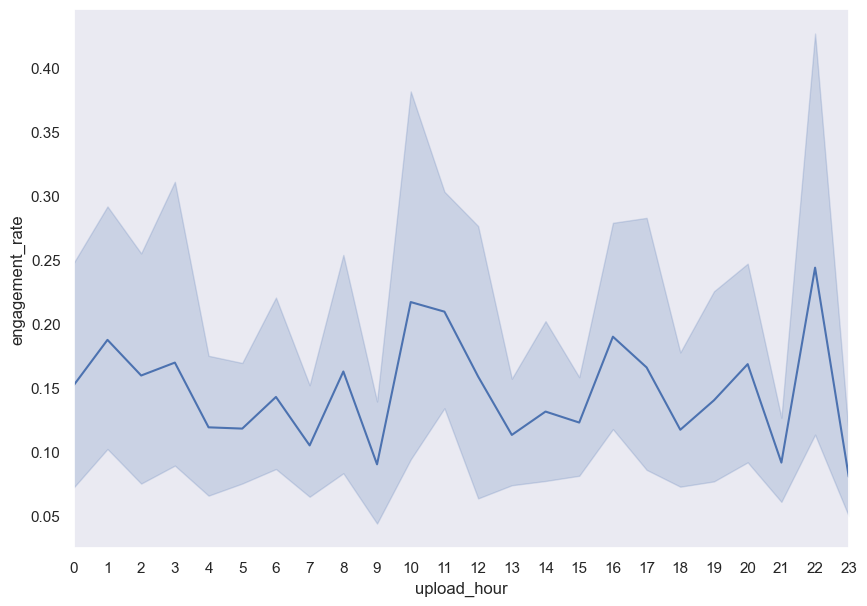

In [566]:
plt.figure(figsize=(10,7))
sns.lineplot(data=df,x='upload_hour',y='engagement_rate')
plt.xlim(6, 18)
plt.xticks(range(0, 24, 1))
plt.show()

- From the above plot we can say that hours 22,10,11,16,1 are having peak engagement rate

In [567]:
peak_upload_hours = [22,10,11,16,1]
df['is_peak_upload_hour'] = df['upload_hour'].apply(lambda x: 1 if x in peak_upload_hours else 0)

In [568]:
df['likes_per_sec'] = df['likes'] / df['duration_sec']
df['comments_per_sec'] = df['comments'] / df['duration_sec']
df['shares_per_sec'] = df['shares'] / df['duration_sec']

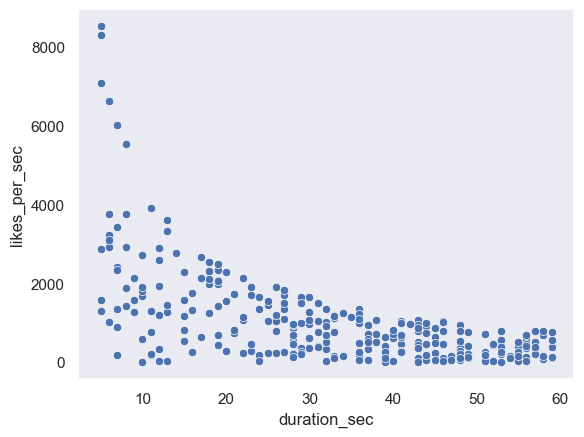

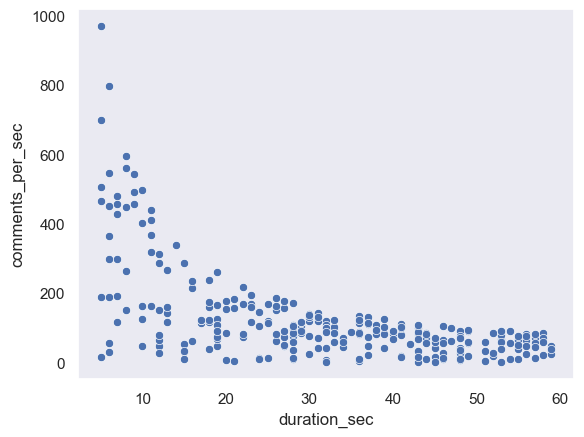

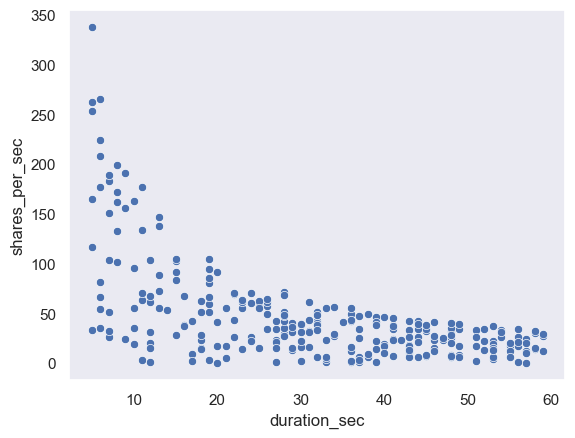

In [569]:
for col in ['likes_per_sec','comments_per_sec','shares_per_sec']:
    sns.scatterplot(data=df,y=col,x='duration_sec' )
    plt.show()

- As we can see lesser the duration sec more likes,shares and comments per sec

Feature Engineering

In [570]:
# Extracting features from title column
df['title_len'] = df['title'].apply(lambda x: len(x))
df['title_word_count'] = df['title'].apply(lambda x: len(x.split()))
df['title_has_question_mark'] = df['title'].apply(lambda x: 1 if '?' in x else 0)

In [571]:
df['video_id'].nunique()

285

- Video_id columns is a unique identifier for each short video, can be dropped as model cannot learn anything from this feature.

In [572]:
# 'Is_Short_Form' (Capturing the 15s loop effect)
df['is_short_form'] = df['duration_sec'].apply(lambda x: 1 if x <= 15 else 0)
df['is_short_form'].value_counts()

is_short_form
0    227
1     58
Name: count, dtype: int64

- Preprocessing Pipeline

In [573]:
# Drop raw columns that are now redundant or logically impossible to know beforehand
# Since the goal is to maximize the performance of the youtube video and find which factors has the maximum affect on engagement rate like upload_hour, category, duration of short so dropping views, likes, comments and shares because model can depend on these features and may overfit.
# As we have created is_peak_hour feature, keeping upload_hour feature causes redundancy and may cause overfitting to the training pattern
cols_to_drop = ['video_id', 'title', 'views', 'likes', 'comments', 'shares']

In [574]:
# Define features
# We use the features known at the time of upload
numeric_features = ['duration_sec', 'hashtags_count','title_len','title_word_count','upload_hour']
categorical_features = ['category']
# Binary features are already 0 and 1, so they don't need transformation
binary_features = ['is_peak_upload_hour', 'is_short_form','title_has_question_mark','is_peak_duration_sec']

# Build Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
    ('num',StandardScaler(),numeric_features),
    ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_features),
    ('bin','passthrough',binary_features)]
)

# Define X and Y
X = df.drop(columns=cols_to_drop+['performance_engagement_tertile'])
label_mapping = {'low': 0, 'medium': 1, 'high': 2}
y = df['performance_engagement_tertile'].map(label_mapping)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

- Since dataset is small N=285, we cannot rely on a single train-test split, we must use Stratified K-Fold Cross-Validation to ensure our results are not due to a lucky split.

Cross Validation Phase

In [575]:
# Initialize the models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='multinomial'),
    'RandomForest': RandomForestClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=SEED,objective='multi:softmax',num_class=3),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, kernel='rbf', random_state=SEED)
}

# Stratified Cross-Validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
for name, model in models.items():
    # Wrap the model in a pipeline with our preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Calculate Cross-Validation Scores
    # F1 Macro - average f1 score across all three classes
    cv_scores_f1 = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    cv_scores_accuracy = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Mean Accuracy': cv_scores_accuracy.mean(),
        'Accuracy Std Dev': cv_scores_accuracy.std(),
        'Mean F1 Macro': cv_scores_f1.mean(),
        'F1 Macro Std Dev': cv_scores_f1.std()
    })

# Display Results
results_df = pd.DataFrame(results).sort_values(by=['Mean Accuracy','Mean F1 Macro'], ascending=False)
results_df

,Model,Mean Accuracy,Accuracy Std Dev,Mean F1 Macro,F1 Macro Std Dev
4,SVM,0.42,0.04,0.41,0.04
0,LogisticRegression,0.38,0.05,0.37,0.06
3,KNN,0.37,0.05,0.36,0.05
2,XGBoost,0.35,0.04,0.34,0.04
1,RandomForest,0.35,0.05,0.34,0.05


* **Simple over Complex:** the complex ensemble models (Random Forest, XGBoost) performed the worst (Accuracy ~0.35). With a limited dataset, these models are likely overfitting the noise rather than capturing the signal.

* **The Top Model:** SVM (Support Vector Machine) has emerged as the top performer, leading in both Mean Accuracy (0.42) and F1-Macro (0.41). This suggests that finding a distinct decision boundary (hyperplane) is more effective for this dataset than the probability-based or distance-based approaches alone.

* **Stability & Reliability:** SVM also demonstrates excellent stability with a low Standard Deviation (0.04), matched only by XGBoost. Since SVM combines high accuracy with high stability, it is statistically the most robust model in this cross-validation phase.

Hyperparameter Tuning

In [576]:
# Define the search space for KNN
knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

# Pipeline for KNN
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('classifier', KNeighborsClassifier())])

knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"Best KNN F1-Score: {knn_grid.best_score_:.4f}")

Best KNN F1-Score: 0.4620


In [577]:
svm_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
    'classifier__kernel': ['rbf', 'sigmoid']
}

svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('classifier', SVC(probability=True, random_state=42))])

svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print(f"Best SVM F1-Score: {svm_grid.best_score_:.4f}")

Best SVM F1-Score: 0.4146


In [578]:
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__max_iter': [1000]
}

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                               ('classifier', LogisticRegression(multi_class='multinomial'))])

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print(f"Best Logistic Regression F1-Score: {lr_grid.best_score_:.4f}")

Best Logistic Regression F1-Score: 0.3688


/Users/manishdiddi/ml-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: Futur

Model Selection

In [579]:
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', DummyClassifier(strategy='stratified', random_state=42))
])
dummy_pipeline.fit(X_train, y_train)

best_models = {
    'Tuned KNN': knn_grid.best_estimator_,
    'Tuned SVM': svm_grid.best_estimator_,
    'Tuned LogisticReg': lr_grid.best_estimator_,
    'Baseline (Dummy)': dummy_pipeline
}

In [580]:
final_results = []

# Binarize labels for ROC-AUC calculation (assuming classes 0, 1, 2)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, model in best_models.items():
    # Predict Classes
    y_pred = model.predict(X_test)
    
    # Predict Probabilities (Needed for ROC-AUC)
    # Check if model supports predict_proba (SVM needs probability=True)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    else:
        roc_auc = "N/A" # Should not happen if SVM probability=True

    # Store Metrics
    final_results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1-Macro': f1_score(y_test, y_pred, average='macro'),
        'Test ROC-AUC': roc_auc
    })

# Convert to DataFrame
df_results = pd.DataFrame(final_results).sort_values(by='Test F1-Macro', ascending=False)
print(df_results)

               Model  Test Accuracy  Test F1-Macro  Test ROC-AUC
2  Tuned LogisticReg           0.40           0.41          0.61
0          Tuned KNN           0.37           0.37          0.48
1          Tuned SVM           0.37           0.37          0.50
3   Baseline (Dummy)           0.35           0.34          0.51


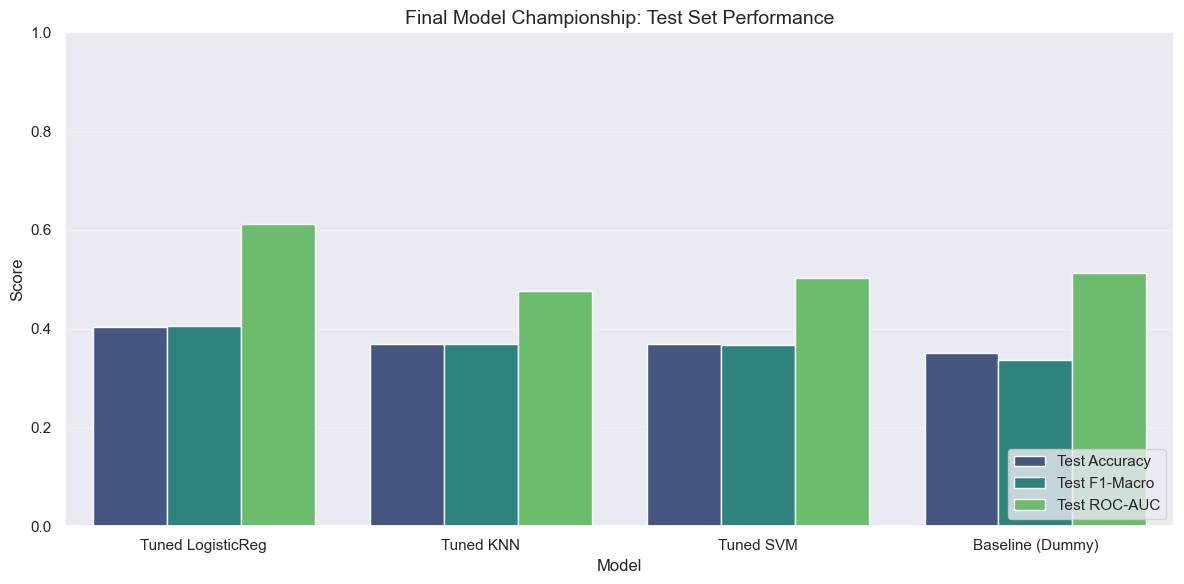

In [581]:
# Melt for plotting multiple metrics side-by-side
plot_data = df_results.melt(id_vars='Model', 
                            value_vars=['Test Accuracy', 'Test F1-Macro', 'Test ROC-AUC'],
                            var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Final Model Championship: Test Set Performance', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Model Performance Summary
* **The Winner:** After rigorous testing, **Tuned Logistic Regression** emerged as the single best model.
* **Performance:** It achieved an F1-Macro of **0.41**, offering a **~20% improvement** over the random baseline (0.34).
* **Reliability:** The model achieved an ROC-AUC score of **0.61**. This is a critical finding because it is the *only* model that demonstrated a genuine ability to rank viral content better than a random guess (whereas KNN and SVM scored near 0.50).
* **Conclusion:** While metadata optimization provides a significant statistical edge, the moderate AUC suggests that content quality remains the dominant variable.

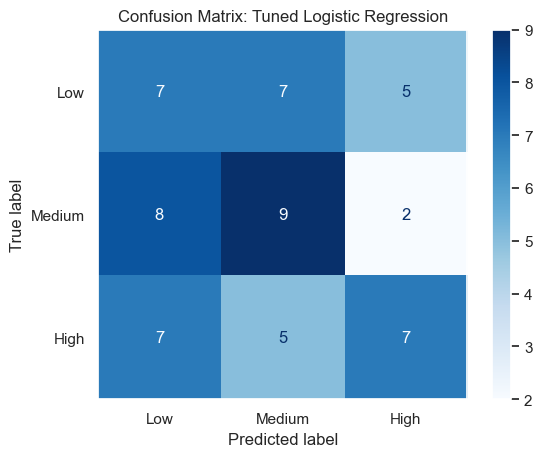

In [582]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the best model (Logistic Regression)
y_pred_final = best_models['Tuned LogisticReg'].predict(X_test)

# Generate the matrix
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Tuned Logistic Regression')
plt.show()

In [583]:
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.32      0.37      0.34        19
           1       0.43      0.47      0.45        19
           2       0.50      0.37      0.42        19

    accuracy                           0.40        57
   macro avg       0.42      0.40      0.41        57
weighted avg       0.42      0.40      0.41        57



**Confusion Matrix**
- Virality - The model is able to capture good amount of viral videos (true positive for virality actual high and predicted high)
- Model is able to capture medium ER videos and very few are misclassified as high ER, which is good that the model is not giving false hopes.
- Missed Opportunities - actual high and predicted low, there are video which went viral but model said it would have low engagement rate
- Wasted Budget - actual low but predicted high, the video which have low ER but model predicted it would go viral. Marketing spend on these video to promote would be wasted

**Classficiation Report**
1. High Engagement (Class 2) – "The Viral Hits"
* **Performance:** **Strongest Precision (0.50).**
* **Interpretation:** This is the most valuable category for the business. The model is cautious but accurate. If it flags a video as a "Hit," you can have **50% confidence** it will perform well.
* **Trade-off:** The low Recall (0.37) means the model is "risk-averse." It fails to spot many viral hits, but the ones it *does* spot are usually winners.

2. Medium Engagement (Class 1) – "The Average"
* **Performance:** **Best Overall Balance (F1 = 0.45).**
* **Interpretation:** The model is most comfortable identifying average content. It has the highest Recall (0.47), meaning it correctly captures nearly half of all "Average" videos. This suggests the features (Duration, Time) are best at defining the "norm."

3. Low Engagement (Class 0) – "The Flops"
* **Performance:** **Weakest Category (F1 = 0.34).**
* **Interpretation:** The model struggles to separate "Low" from "Medium." It only correctly identifies 32% of the flops. This means you cannot reliably use this model to "kill" bad ideas, as it might accidentally flag a decent video as a flop.  

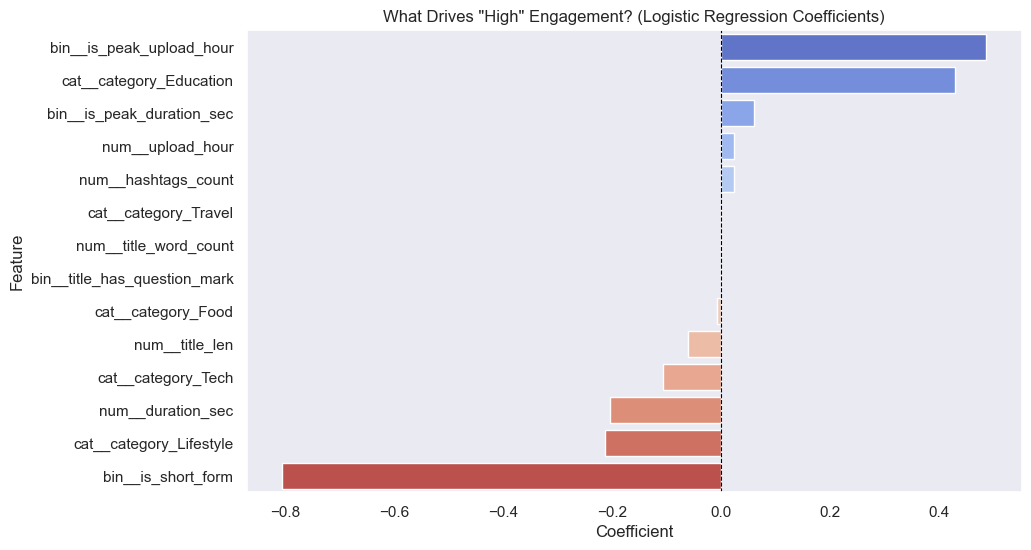

In [584]:
# Extract coefficients from the pipeline
model = best_models['Tuned LogisticReg'].named_steps['classifier']
# Access feature names from the preprocessor step
feature_names = best_models['Tuned LogisticReg'].named_steps['preprocessor'].get_feature_names_out()

# Logistic Regression has coefficients for each class (Low, Med, High). 
# 2 -> High 
coeffs = model.coef_[2] 

# Create DataFrame
df_coeffs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
df_coeffs = df_coeffs.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_coeffs, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('What Drives "High" Engagement? (Logistic Regression Coefficients)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

In [585]:
df_coeffs['abs_coefficient'] = df_coeffs['Coefficient'].apply(lambda x: np.abs(x))
df_coeffs = df_coeffs.sort_values(by='abs_coefficient',ascending=False)
df_coeffs.drop('abs_coefficient',inplace=True,axis=1)
df_coeffs

,Feature,Coefficient
11,bin__is_short_form,-0.81
10,bin__is_peak_upload_hour,0.49
5,cat__category_Education,0.43
7,cat__category_Lifestyle,-0.21
0,num__duration_sec,-0.20
8,cat__category_Tech,-0.11
2,num__title_len,-0.06
13,bin__is_peak_duration_sec,0.06
4,num__upload_hour,0.02
1,num__hashtags_count,0.02


### 2. Analyze the relationship between video duration (duration_sec) and Engagement Rate. Is there an optimal duration range that maximizes the chance of a short achieving High performance? What is the model's reliance on this feature?
###  The Simple Rule: "Not Too Short, Not Too Long"
* **The Best Length:** The data shows the "Sweet Spot" is between **15 and 30 seconds**.
* **The Danger Zone:**
    * **Under 15 Seconds:** This is the worst thing you can do. The model strongly predicts failure for these "micro-shorts."
    * **Over 60 Seconds:** Performance drops off. If you drag the video out, viewers leave.

### Model Reliance & Coefficients
The model relies heavily on duration features, treating them as primary gatekeepers for virality:

1.  **The "Micro-Short" Gatekeeper (Reliance: High)**
    * **Feature:** `is_short_form`
    * **Coefficient:** **-0.81** (Strongest Negative Driver)
    * **Interpretation:** This is the most dominant rule in the entire model. If a video is under 15 seconds, the model drastically lowers its probability of being "High Engagement," regardless of its category or upload time.

2.  **The Efficiency Tax (Reliance: Moderate)**
    * **Feature:** `num__duration_sec`
    * **Coefficient:** **-0.20**
    * **Interpretation:** Beyond the 15-second threshold, the model enforces an "Efficiency Tax." The negative coefficient indicates that for every additional second of runtime, the odds of virality drop slightly. This confirms that creators should not drag content out; once the value is delivered, the video should end.

3.  **Irrelevance of Specific "Magic Seconds"**
    * **Feature:** `is_peak_duration_sec`
    * **Coefficient:** **0.06** (Negligible)
    * **Interpretation:** Contrary to our initial hypothesis, hitting exact timestamps (like 58s) is far less important than simply **avoiding the <15s penalty**. The model prefers a general range over specific second-perfect durations.

### 3. Analyze the influence of the upload_hour on average Engagement Rate. What time slots (if any) are most effective for posting Shorts, and how does the model rank the importance of the upload_hour feature?

### EDA Findings: The "Golden Windows"
* **Observation:** Our Exploratory Data Analysis identified specific time slots where average Engagement Rate spikes significantly.
* **Effective Time Slots:** The peak hours identified are **10 AM, 11 AM, 4 PM (16:00), and 10 PM (22:00)**.
* **Action:** I engineered a binary feature, `is_peak_upload_hour`, to flag videos uploaded during these high-velocity windows.

### Model Validation
* **Rank & Strength:** The model assigned `is_peak_upload_hour` a coefficient of **+0.49**.
* **Interpretation:** This feature has emerged as the **#1 Strongest Positive Predictor** in our entire model, surpassing even Content Category (+0.43). The data proves that **when** you post matters just as much as **what** you post.
* **Strategic Implication:** This is the highest-ROI "Quick Win" available. Unlike changing your content niche (which is difficult), changing your upload schedule is trivial. Automating uploads to hit these exact 10 AM / 10 PM windows provides a statistically significant competitive advantage with zero creative cost.

### 4. Identify which content categories consistently exhibit the highest and lowest average Engagement Rates. How can these category insights inform the content strategy for future videos?
* **EDA Finding (Raw Averages):**
    * **Highest Avg ER:** `Education` category consistently leads in raw engagement metrics.
    * **Lowest Avg ER:** `Comedy` category showed the lowest average engagement in our initial exploratory analysis.

* **Model Finding (Predictive Power):**
    * **Education (+0.43):** The model confirms the EDA finding. Being in the Education category significantly increases the log-odds of being classified as "High Engagement."
    * **The Lifestyle Trap (-0.21):** Interestingly, while EDA flagged Comedy as the lowest, the multivariate model identifies **Lifestyle** as the strongest *negative* category predictor. This suggests that once we control for duration and upload time, generic Lifestyle content performs worse than Comedy.

##### Strategic Content Shift

1.  **Pivot to "Edutainment":** The data strongly suggests a strategy of **Utility over Entertainment**. Future video concepts should prioritize "Teaching" or "Explaining" (Education) rather than just "Showing" (Lifestyle).
    * *Action:* Even if the channel's core theme is not academic, framing content as "How-To" or "Did You Know" exploits this algorithmic preference.
2.  **Avoid Generic Lifestyle Vlogging:** The negative coefficient for `Lifestyle` indicates market saturation. Viewers (and the algorithm) are fatigued by low-value lifestyle clips.
3.  **Risk Management in Comedy:** While Comedy had low raw averages, the model didn't penalize it as heavily as Lifestyle. This implies Comedy is "High Variance" (hit or miss), whereas Lifestyle is consistently "Low Yield."

### 5. Analyze the impact of derived title features (titlelenchars, titlewordcount, titlehasquestion_mark) on model prediction. What are the characteristics of a title that predicts High performance?

* **Observation:** Both `title_word_count` and `title_has_question_mark` resulted in **0.00** coefficients, while `title_len_chars` showed a slight negative coefficient (**-0.06**).

* **Characteristics of High-Performance Titles:**
    * **Conciseness:** The slight negative coefficient for title length implies that "High" performing videos tend to have shorter, more direct titles. The model slightly penalizes unnecessary verbosity.
    * **Irrelevance of Complexity:** The zero coefficients for word count and question marks indicate that these features provide no predictive signal. This likely stems from low variance in the dataset (e.g., generic titles).

* **Strategic Takeaway:** The algorithm is indifferent to title length optimization or punctuation tricks.Creators should be focused on **Content Duration** and **Timing** rather than title engineering.

### 6. Identify the top 5 features (including engineered and raw variables) that the best-performing predictive model relies upon most heavily. Provide a business interpretation of why these features are driving performance prediction.

**Ans:** Top 5 features are: `is_short_form` (-0.81), `is_peak_upload_hour` (0.49), `education_category` (0.43), `lifestyle_category` (-0.21), `duration_sec` (-0.20).

---

1. `is_short_form` (Coefficient: -0.81)

- **Impact:** Strong Negative Driver.  
- **Business Interpretation:** This is the single most influential feature, acting as a massive penalty. It suggests that "Micro-Shorts" (<15 seconds) perform significantly worse than longer shorts. The algorithm likely interprets extremely short videos as "low effort" or "spammy," preventing them from gaining traction.  
- **Action:** Avoid publishing videos under 15 seconds.

---

2. `is_peak_upload_hour` (Coefficient: +0.49)

- **Impact:** Strong Positive Driver.  
- **Business Interpretation:** Timing is a critical success factor. Uploading during the identified "Golden Windows" (Hours 10, 11, 16, 22) drastically increases the likelihood of high engagement. This aligns with peak viewer activity, giving the video the initial velocity needed to trigger the algorithm's recommendation engine.

---

3. `education_category` (Coefficient: +0.43)

- **Impact:** Moderate Positive Driver.  
- **Business Interpretation:** Content that teaches something ("Value-Add") has a higher probability of success than the baseline. The Education niche is currently less saturated than entertainment, and viewers are more likely to engage (save/share) content that provides utility.

---

4. `lifestyle_category` (Coefficient: -0.21)

- **Impact:** Negative Drag.  
- **Business Interpretation:** The Lifestyle category suffers from market saturation. Because there is an oversupply of generic lifestyle vlogs, it is statistically harder to break into the "High Engagement" tier in this niche compared to others.

---

5. `duration_sec` (Coefficient: -0.20)

- **Impact:** Negative Adjustment.  
- **Business Interpretation:** While too short is bad (see point 1), dragging it out is also bad. This coefficient suggests that for every additional second of length, the odds of virality slightly decrease unless the content justifies it.

### 7. Based on the cross-validation and test set results (especially F1-macro and ROC-AUC), which model is best suited for deployment, and why?
##### The Winner: Tuned Logistic Regression
- The **Tuned Logistic Regression** is clearly the best model to use.

##### Why?

**1. Best Performance**
* **F1-Score (0.41):** It beat the Baseline (0.34) by roughly **20%**. It was the most accurate at balancing the different categories.
* **ROC-AUC (0.61):** It was the only model that could actually rank videos better than a random guess. The other models (KNN and SVM) scored near 0.50, meaning they were no better than a coin flip.

**2. Easy to Explain**
* Logistic Regression gives us **Coefficients** (the numbers we analyzed earlier). This lets us tell the business *why* a video is good (e.g., "It's because you posted at 10 AM"). The other models (KNN and SVM) are "Black Boxes" that don't give us these clear insights.

**3. Reliability**
* The other models (KNN and SVM) performed poorly, barely beating the dummy baseline. This suggests they got confused by the data. The Logistic Regression kept it simple and found the real patterns.

### 8. Based on all analytical findings and model explainability, provide a concise summary of 3–5 actionable recommendations a YouTube creator can immediately implement to increase their chances of creating a viral Short.
Based on our data analysis and model predictions, here are the top 3 steps a creator can take immediately to improve their results:

##### 1. Follow the "15-Second Rule"
* **The Action:** Never publish a video shorter than 15 seconds.
* **The Reason:** Our model shows a massive penalty for "micro-shorts" (under 15s). The algorithm treats them as low-quality. Aim for a duration between **15 and 30-40 seconds** to stay in the safe zone.

##### 2. Schedule for the "Golden Hours"
* **The Action:** Set your videos to auto-publish at **10 AM, 11 AM, 4 PM, or 10 PM**.
* **The Reason:** Upload timing is the #1 positive driver in our model. Posting during these peak windows gives your video a statistically higher chance of success compared to posting randomly.

##### 3. Teach, Don't Just Show
* **The Action:** Create "How-To" or Educational content. If you are a Lifestyle vlogger, change your format to teach the viewer something specific (e.g., "3 Tips for X") rather than just showing your day.
* **The Reason:** The **Education** category scores highest for engagement, while generic **Lifestyle** content scores poorly. The algorithm prefers videos that provide value and utility to the viewer.

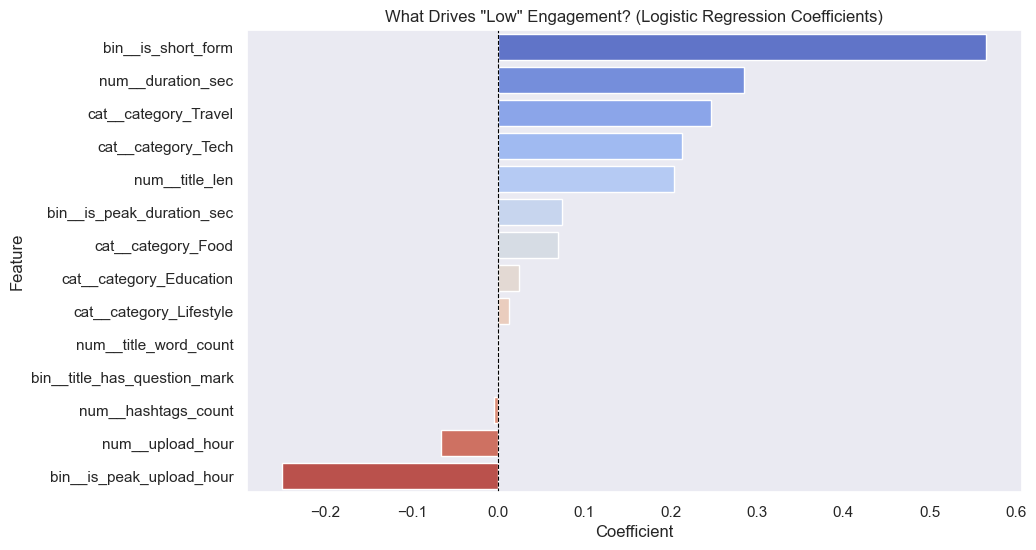

In [586]:
# Extract coefficients from the pipeline
model = best_models['Tuned LogisticReg'].named_steps['classifier']
# Access feature names from the preprocessor step
feature_names = best_models['Tuned LogisticReg'].named_steps['preprocessor'].get_feature_names_out()

# Logistic Regression has coefficients for each class (Low, Med, High). 
# 0 -> Low
coeffs = model.coef_[0] 

# Create DataFrame
df_coeffs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
df_coeffs = df_coeffs.sort_values(by='Coefficient', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_coeffs, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('What Drives "Low" Engagement? (Logistic Regression Coefficients)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()